In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.stats import ttest_rel

In [ ]:
psth_coor = pd.read_csv('./data/psth_displacement_by_epoch_v2.csv')
psth_coor['subject'] = psth_coor['fix_date'].str.split('_').str[0]

disp_features = ['TipTongue_disp', 'MEdgeR_disp', 'MEdgeL_disp']
psth_coor['avg_disp_tongue'] = psth_coor[disp_features].mean(axis=1)

disp_features = ['mean_R_disp', 'mean_L_disp']
psth_coor['avg_disp_limbs'] = psth_coor[disp_features].mean(axis=1)

In [3]:
plot = psth_coor.loc[psth_coor.delay == 10].copy()
plot['epoch'] = np.where(
    plot['bin'].between(11, 14), 'Response',
    np.where(
        plot['bin'].between(7.0, 10.0), 'Delay',
        np.where(
            plot['bin'].between(-0.5, 0), 'Baseline',
            0
        )
    )
)
plot = plot.loc[plot.epoch != 0]

In [4]:
sns.set_context("paper")

def plot_lines(data, ax, variable='total_rewards', group='patch_label', one_line='mouse', order=None):
    if order is None:
        order = sorted(data[group].unique())
    x_map = {label: i for i, label in enumerate(order)}
    for value in data[one_line].unique():
        df_subset = data[data[one_line] == value]
        y = df_subset[variable].values
        x_labels = df_subset[group].values
        x = [x_map[label] for label in x_labels]
        lst_new = [x[0]-0.925, x[1]-0.075]
        ax.plot(lst_new, y, marker='', linestyle='-', color='black', alpha=0.4, linewidth=1)

## PSTH line plot — WM correct vs incorrect

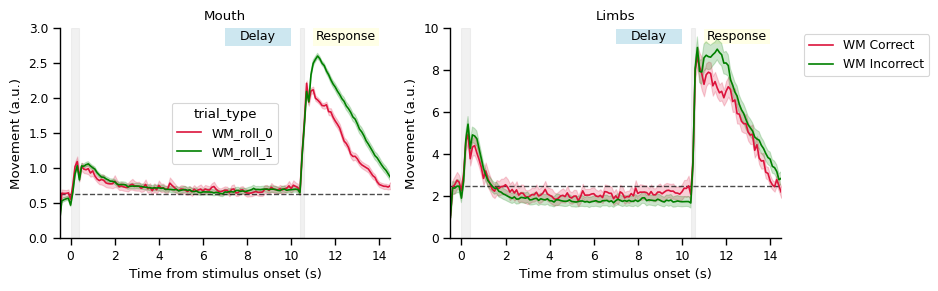

In [5]:
delay = 10
trials = ['WM_roll_1', 'WM_roll_0']

features_to_plot = ['avg_disp_tongue', 'avg_disp_limbs']
n_features = len(features_to_plot)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    plot_data = psth_coor.loc[psth_coor['trial_type'].isin(trials)].groupby(
        ['bin', 'trial_type', 'fix_date', 'delay']
    )[feature].mean().reset_index()

    sns.lineplot(
        data=plot_data.loc[(plot_data.delay == delay) & (plot_data.trial_type != 'nan')],
        x='bin', y=feature, hue='trial_type',
        palette={'WM_roll_0': "crimson", 'WM_roll_1': "green", 'RL_roll_1': "indigo", 'RL_roll_0': "pink"},
        errorbar='se', ax=ax
    )

    baseline_mean = plot_data.loc[(plot_data['bin'] < 0) & (plot_data['bin'] > -0.5), feature].mean()
    ax.axhline(baseline_mean, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

    ax.axvspan(10.4, 10.6, ymin=0, ymax=1, color='lightgray', alpha=0.3, zorder=0)
    ax.axvspan(0., 0.4, ymin=0, ymax=1, color='lightgray', alpha=0.3, zorder=0)
    ax.set_xlim(-0.5, delay + 4.5)
    ax.set_xticks(np.arange(0, delay + 5, 2))
    ax.set_title('Mouth' if feature == 'avg_disp_tongue' else 'Limbs')

    if feature == 'avg_disp_limbs':
        y_max, line, thickness = 10, 9.25, 0.7
    else:
        y_max, line, thickness = 3, 2.75, 0.4
    ax.set_ylim(0, y_max)

    rect1 = patches.Rectangle((7, line), 3, thickness, linewidth=0, facecolor='lightblue', alpha=0.6, zorder=0)
    ax.add_patch(rect1)
    ax.text(8.5, y_max * 0.99, 'Delay', color='black', ha='center', va='top', fontsize=9, zorder=10)

    rect2 = patches.Rectangle((11, line), 3, thickness, linewidth=0., facecolor='lightyellow', alpha=0.8, zorder=0)
    ax.add_patch(rect2)
    ax.text(12.5, y_max * 0.99, 'Response', ha='center', color='black', va='top', fontsize=9, zorder=10)

    sns.despine(ax=ax)
    ax.set_ylabel('Movement (a.u.)')
    ax.set_xlabel('Time from stimulus onset (s)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['WM Correct', 'WM Incorrect'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1. 2. Movement correlations with outcome\x_bin_y_avg_disp_hue_state_{trials}.svg")
plt.show()

## Boxplot by epoch — WM correct vs incorrect

Baseline (avg_disp_limbs): t=1.604, p=0.1599, n=7
Delay (avg_disp_limbs): t=-0.183, p=0.8609, n=7
Response (avg_disp_limbs): t=0.961, p=0.3739, n=7


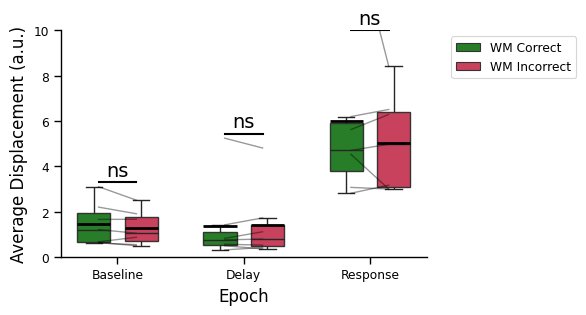

Baseline (avg_disp_tongue): t=-0.920, p=0.3929, n=7
Delay (avg_disp_tongue): t=1.811, p=0.1200, n=7
Response (avg_disp_tongue): t=9.081, p=0.0001, n=7


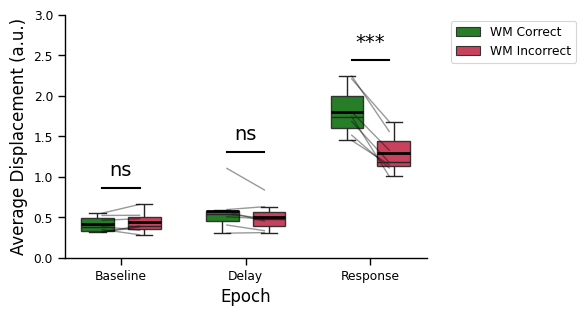

In [6]:
epoch_order = ['Baseline', 'Delay', 'Response']
trial_type = ['WM_roll_1', 'WM_roll_0']

for feature in ['avg_disp_limbs', 'avg_disp_tongue']:
    show = (
        plot.loc[plot.trial_type.isin(trial_type)]
            .groupby(['epoch', 'trial_type', 'subject', 'fix_date', 'bin'])[feature].mean()
            .reset_index()
            .groupby(['epoch', 'trial_type', 'subject', 'fix_date'])[feature].mean()
            .reset_index()
            .groupby(['epoch', 'trial_type', 'subject'])[feature].median()
            .reset_index()
    )

    fig, ax = plt.subplots(figsize=(6, 3.25))
    sns.boxplot(
        data=show, x='epoch', y=feature, hue='trial_type',
        order=epoch_order,
        palette={'RL_roll_1': "indigo", 'WM_roll_1': "green", 'WM_roll_0': "crimson", 'RL_roll_0': "pink"},
        showfliers=False, hue_order=trial_type, width=0.75, gap=0.3,
        boxprops=dict(alpha=0.9), showmeans=True, meanline=True,
        meanprops=dict(color='black', ls='-', lw=2)
    )

    hue_off = {trial_type[0]: -0.15, trial_type[1]: +0.15}
    for i, ep in enumerate(epoch_order):
        sub = show.loc[show.epoch == ep]
        for subj in sub['subject'].unique():
            d = sub.loc[sub.subject == subj]
            pts = {tt: d.loc[d.trial_type == tt, feature].values for tt in trial_type}
            if any(len(v) == 0 for v in pts.values()):
                continue
            xs = [i + hue_off[trial_type[0]], i + hue_off[trial_type[1]]]
            ys = [pts[trial_type[0]][0], pts[trial_type[1]][0]]
            ax.plot(xs, ys, marker='', linestyle='-', color='black', alpha=0.4, linewidth=1)

    for i, ep in enumerate(epoch_order):
        sub = show.loc[show.epoch == ep]
        cond0 = sub.loc[sub.trial_type == trial_type[0]].set_index('subject')[feature]
        cond1 = sub.loc[sub.trial_type == trial_type[1]].set_index('subject')[feature]
        common = cond0.index.intersection(cond1.index)
        if len(common) < 2:
            continue
        t_stat, p_val = ttest_rel(cond0.loc[common], cond1.loc[common])
        print(f"{ep} ({feature}): t={t_stat:.3f}, p={p_val:.4f}, n={len(common)}")

        x1, x2 = i + hue_off[trial_type[0]], i + hue_off[trial_type[1]]
        y = sub[feature].max() + 0.2
        if y > 10:
            y = 10
        ax.plot([x1, x2], [y, y], color='black', lw=1.5)
        if p_val < 0.001: sig = "***"
        elif p_val < 0.01: sig = "**"
        elif p_val < 0.05: sig = "*"
        else: sig = "ns"
        ax.text(i, y + 0.1, sig, ha='center', va='bottom', fontsize=14)

    plt.legend(handles=ax.get_legend_handles_labels()[0],
               labels=['WM Correct', 'WM Incorrect'],
               bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.ylim(0, 3 if feature == 'avg_disp_tongue' else 10)
    plt.ylabel('Average Displacement (a.u.)', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.tight_layout()
    plt.savefig(rf"G:\My Drive\WORKING_MEMORY\PAPER\2ND_SUBMISSION_NAT_NEURO\figures_for_resubmission\Fig. 1. 2. Movement correlations with outcome\allepochs_avg_disp_boxplot_{trial_type}_{feature}.svg")
    plt.show()